In [1]:
from config import *
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option('display.max_colwidth', None)
plt.style.use('default')

Nate Lewin\
FTMBA Class of 2027, UC Berkeley Haas\
linkedin.com/in/njlewin/\
github.com/njlewin/

# Executive Summary

In 2025 the NFL introduced new overtime rules. Under prior rules, the consensus opinion was that the receiving team was at an advantage; the game was sudden-death (or a modified sudden-death) and the receiving team had the opportunity to end the game outright on their first offensive possession. Under the new rules which guarantee both teams at least one possession, the advantage is less clear. After one full season with the new rules, NFL coaches remain split on the decision, and, with only 17 games played under the rule, the sample size is too small to determine the correct outcome. In order to determine the optimal decision, tens of thousands of overtimes were simulated under the new ruleset in order to determine the long-run average result between kicking and receiving.

The results found that the receiving team has a 7.6% win rate advantage over the kicking team. The core reason for this is after the two guaranteed possessions each possession is less likely than the last. 57.0% of overtimes end in two possessions, 21.2% of overtimes end on the third possession, 11.9% end on the fourth possession. 5.9% on the fifth, and so on. Games that end in two possessions slightly favor the kicking team, as they have the advantage of knowing what the receiving accomplished on their first possession and can plan appropriately. However, games that last at least three possessions overwhelmingly favor the receiving team, as they have the first chance to end the game once it is effectively sudden-death.

The kicking team has several decision points where they can optimize their play. Going for two point conversions when the kicking team scores a touchdown to match the receiving team reduces the advantage by 2%, as the conversion rate on a two point attempt is better than their win rate on overtimes that go to a third possession. Though they should play conservatively on game tying field goals, as their odds of winning or tying are better than the odds of converting a fourth down attempt and subsequently scoring a touchdown.

# Introduction
For most of the NFL's history, the overtime decision was straightforward: if you win the coin toss, choose to receive. Under pure sudden-death rules, in place until 2012, the first score ended the game outright whether it was a touchdown or a field goal. Having the first opportunity to score was an unquestioned advantage. Eventually, games decided by a sudden-death field goal were deemed anticlimactic and unfair to the losing team, prompting a rule change. Beginning in 2012, a touchdown on the first drive would still end the game immediately, but a field goal would give the opposing team the opportunity to respond. The receiving team still had the opportunity to end the game on the first drive, and consensus remained that receiving was the optimal choice.

High-profile overtimes continued to draw criticism, particularly when dramatic offensive duels ended with only one team touching the ball in overtime. The 2021 AFC Championship Game between the Chiefs and Bills, marked by Patrick Mahomes engineering a historic game-tying drive with only 13 seconds remaining in regulation, ended when the Chiefs scored a touchdown on the opening drive in overtime, never giving Josh Allen and the Bills an opportunity to respond. To address this, and to offset the increasing likelihood of scoring drives as kickoff rules gave teams better starting field position, the NFL adopted a new rule guaranteeing both teams a possession regardless of the opening score, first in the playoffs starting in 2023 and then league-wide in 2025.

The advantage under the new rules is no longer clear. The receiving team has the ball first and gets the first opportunity to end the game once effective sudden-death begins. But the kicking team has the advantage of information: they know exactly what they need to do based on what the receiving team accomplished on first possession. If the receiving team scores a touchdown on the opening drive of overtime, the kicking team knows it must convert on fourth downs to stay alive. If they settle for a field goal, the kicking team knows a field goal ties and a touchdown wins.

The tension between these advantages was on full display at Super Bowl LVIII, the first game played under the new rules. The 49ers won the coin toss and opted to receive, and the Chiefs were visibly surprised, as this was their preferred outcome as well. "They want it, they can have it," Chiefs tight end Travis Kelce told his sideline after the toss. The Chiefs won the game with a touchdown after the 49ers scored a field goal. After the first full regular season under these rules in 2025, NFL teams remained split on the decision. Only 17 games have been played with the new rules so far, providing insufficient data to draw conclusions. This paper uses Monte Carlo simulation of NFL overtime periods to provide an answer on what is the optimal decision between kicking and receiving in the new overtime rules. In addition, it examines the secondary question of whether the kicking team should play aggressively for the win or accept a tie to extend play on a matching drive.


# Methodology
The model simulates NFL overtime periods using historical play-by-play data. The goal is to find a random historical analog to the game situation, apply that result to the modeled game state, and iterate until the game is complete by the given overtime rules. By repeating the random simulations enough (10,000 for our purposes), the results will show the long-run average result.

Overtime play is broken into two components: kickoffs and drives. Kickoff results are modeled by sampling randomly from historical kickoffs in the relevant season, producing either a starting field position for the receiving team or a return touchdown. Only kickoffs from the season being modeled are used to account for the frequent rule changes affecting kickoff yard line, touchback location, and the addition of the dynamic kickoff format in 2024.

Drives are modeled by matching the current game state to a historical drive with comparable game conditions. The game conditions considered are the starting yard line, time remaining in the game, and score differential, as these are the key variables that define an offense's approach and the likelihood of drive outcomes. Historical drives are scored by a weighted Euclidean distance across to these three variables, normalized. Yard line and time remaining are normalized by their standard deviation within the dataset, while score differential is normalized by 7, the practical maximum in overtime. Yard line and time remaining are weighted more heavily than score differential given the constrained range of score differentials in overtime.

$$ Score = \sqrt{0.4 \cdot \left(\frac{\Delta\text{yardline}}{\sigma_{\text{yardline}}}\right)^2 + 0.4 \cdot \left(\frac{\Delta\text{time}}{\sigma_{\text{time}}}\right)^2 + 0.2 \cdot \left(\frac{\Delta\text{score differential}}{7}\right)^2}$$

Once all historical drives from the prior 10 years are scored, the 50 closest drives are identified as candidates and one is selected at random, introducing variance in outcomes. The result of the selected drive is applied to the current game situation. Drive results include touchdowns, field goals, punts, turnovers (interception, fumble, turnover on downs, blocked kick), as well as any return touchdowns on turnovers or punts. Following touchdowns, extra points and two-point conversions are modeled at their historical conversion rates of 96.8% and 48.0% respectively and another kickoff is modeled. Following punts turnovers, the opponent begins their next drive where the subsequent drive began historically.

After each score or turnover, the relevant overtime rules are checked to determine if the game should be marked as over. Recent NFL overtime rules can be separated into three buckets:
* 2025 and on, guaranteed possession for each team: The game is over if both teams have had possession and one team is in the lead.
* 2012-2024, modified sudden-death: The game is over if one team scores a touchdown, or if both teams have had possession and one team is in the lead.
* Pre-2012, pure-sudden-death: The game ends when one team is in the lead.

For all cases, the game also ends if time expires or if a safety is scored by either team (regardless of possession). Once the game is marked as over, the simulation ends and the game is marked as a win for either team if one team is ahead or a tie if the score is equal.

Two decision overrides are applied to account for the strategic differences between regulation and overtime. In the regulation games, punting or kicking a field goal may be logical decision when down 7 points, but in overtime those would immediately end the game. So if a sampled drive would result in a punt or field goal that would immediately end the game by overtime rules regardless of outcome, the kick is replaced with a fourth down attempt. The yards-to-go is recorded and matched to a random historical fourth down attempt of similar distance; if successful, a new drive is sampled from the resulting field position to continue the possession. If it fails, possession changes. Second, the kicking team has decision points where they can play conservatively to match the kicking team, or aggressively to go for the win. Specifically, they can attempt a two-point conversion when trailing by one point after a touchdown, or to go for it on fourth down rather than kick a tying field goal when trailing by three points. Both mindsets are modeled to evaluate the impact on win percentage of each decision.

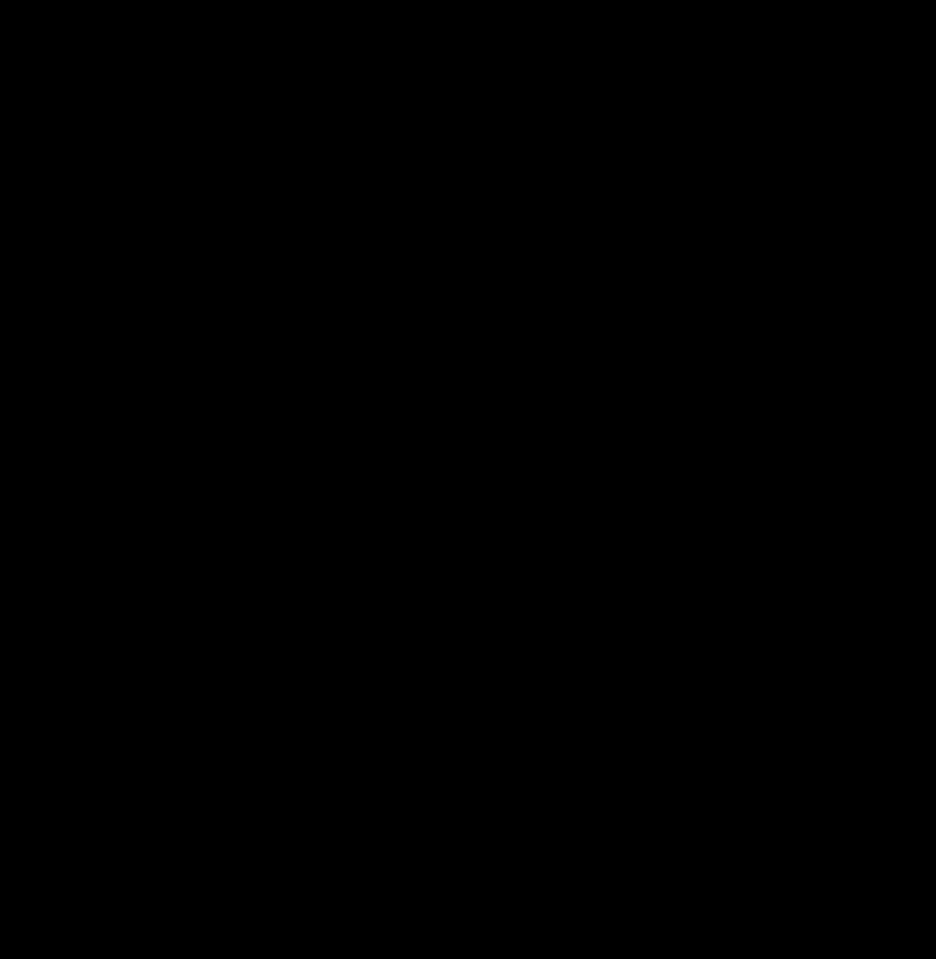
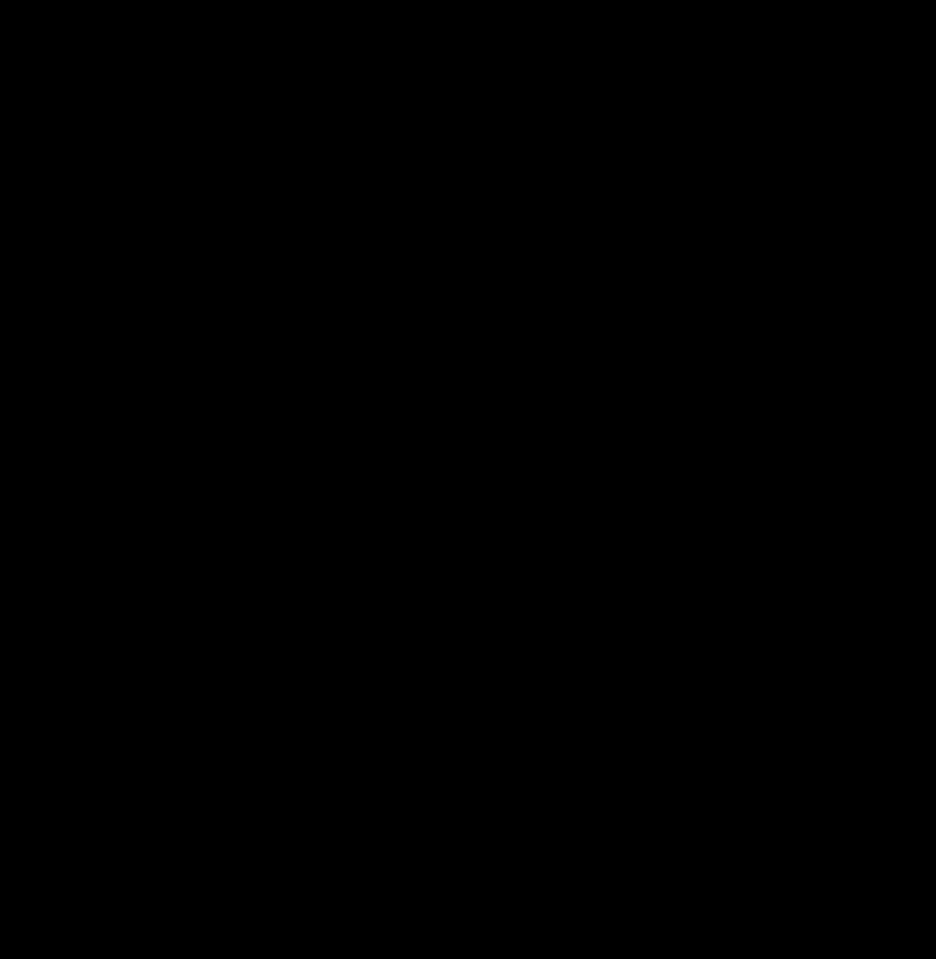
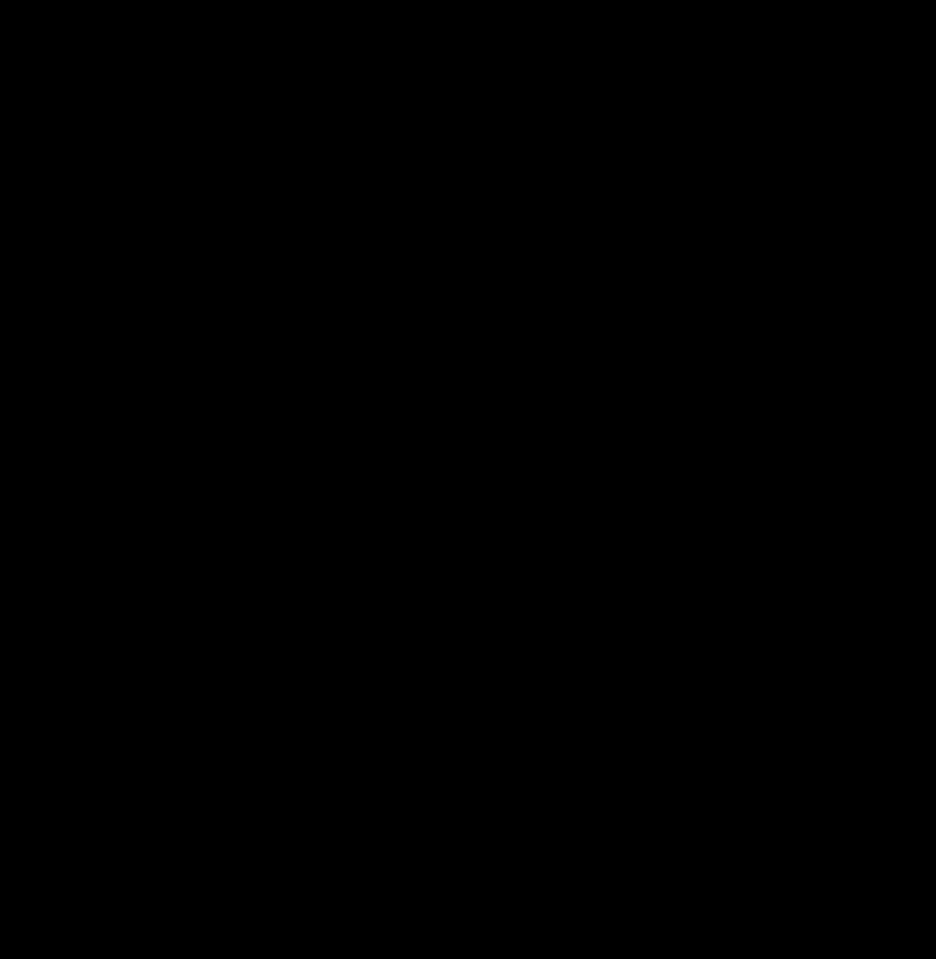
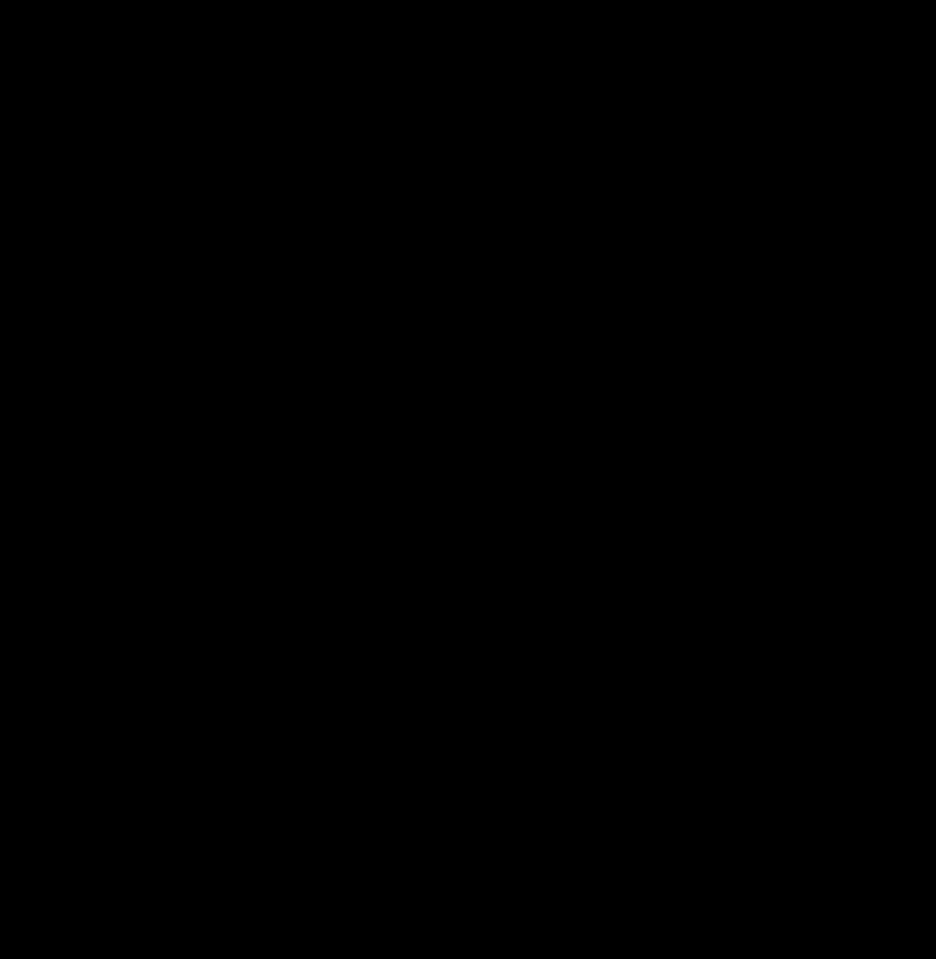

# Results
## Comparison to Historical
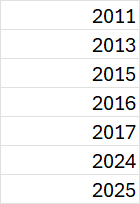

In [2]:
rulesets = pd.read_csv(ASSET_DIR/'overtime_rulesets.csv')
display(rulesets.style.hide(axis='index'))

Ruleset,Overtime Rules,Overtime Length,Kickoff Rules,Avg. Receiving Team Start
Pre 2012,Pure Sudden Death,15 minutes,"Kickoff at the 35 Yardline, Touchback at the 20 Yardline",28
2012-2015,"Sudden Death, except for a first possession field goal",15 minutes,"Kickoff at the 35 Yardline, Touchback at the 20 Yardline",23
2016,"Sudden Death, except for a first possession field goal",15 minutes,"Kickoff at the 35 Yardline, Touchback at the 25 Yardline",26
2017-2023,"Sudden Death, except for a first possession field goal",10 minutes,"Kickoff at the 35 Yardline, Touchback at the 25 Yardline",26
2024,"Sudden Death, except for a first possession field goal",10 minutes,"Dynamic Kickoff Rules, Touchback at the 30 Yardline",30
2025,Both Teams Guaranteed one possession,10 minutes,"Dynamic Kickoff Rules, Touchback at the 35 yard line",31


To evaluate model accuracy, we split the last 20 years into 6 eras with different combinations of overtime and kick-off rules, as starting field position significantly impacts the likelihood of scoring on initial drives. The model was run for a season representative of each ruleset and compared to historical results. To align with traditionally conservative strategy of NFL teams, all simulations go for game-tying field goals and extra points. A key metric evaluated is receiving advantage--the difference in win percentage between receiving teams and kicking teams.


In [3]:
hist_results = pd.read_csv(ASSET_DIR/HIST_COMPARISON)
flat_cols = hist_results.columns
hist_results.columns = pd.MultiIndex.from_tuples([
    (('Historical', c.replace(' Historical', '')) if 'Historical' in c
     else ('Modeled', c.replace(' Modeled', '')) if 'Modeled' in c
     else ('', c))
    for c in flat_cols
])
pct_cols = [(g, c) for g, c in hist_results.columns
            if pd.api.types.is_numeric_dtype(hist_results[g, c]) and hist_results[g, c].abs().between(0, 1).all()]
hist_results.style \
    .format({c: '{:.1%}' for c in pct_cols}) \
    .apply_index(lambda s: ['background-color: #1f77b4; color: white' if v == 'Historical'
                             else 'background-color: #ff7f0e; color: white' if v == 'Modeled'
                             else '' for v in s], axis='columns', level=0) \
    .set_table_styles([{'selector': 'th.col_heading.level0', 'props': [('text-align', 'center')]}]).hide(axis='index')

The historical sample size is  small for most rulesets. Three of the rulesets only have single seasons where they were implemented, so their results are unlikely to be statistically significant. The 56.2% receiving advantage observed in 2024 is likely an outlier caused by low sample size.

Despite limited sample sizes, the model aligns well to historical trends. The Pre-2012 era has the largest historical data set, and the historical receiving advantage (12.0%) closely matches our modeled advantage (11.6%). In the 2012-2015 ruleset, the opportunity to match any opening drive field goals produces near parity between kicking and receiving in the 2012-2015 ruleset in both observed data (6.8%) and modeled (2.6%). Moving the touchback up added more advantage to the receiving team from 2016 until the dynamic kickoff rules were introduced in 2024. In 2024, the receiving team advantage grows to 16.7%, an all-time high. This was driven by the increased average starting field position due to the new dynamic kickoff, while the modified sudden-death rules were still in place. This result further justifies the decision to move to guarantee each team a possession, as first possession advantage had grown substantially.

One observed model bias worth noting is the overestimation of ties in all rulesets, aside from 2016 which could be driven a low sample size. This is likely driven by the regulation play-by-play data being used to simulate drives. In regulation, teams play conservatively near the end of games, content settling for tying scores or running out the clock in anticipation of overtime. Because there is insufficient overtime-specific data to base a complete model on, and mitigating this bias would require too many assumptions, this bias will remain a known limitation.

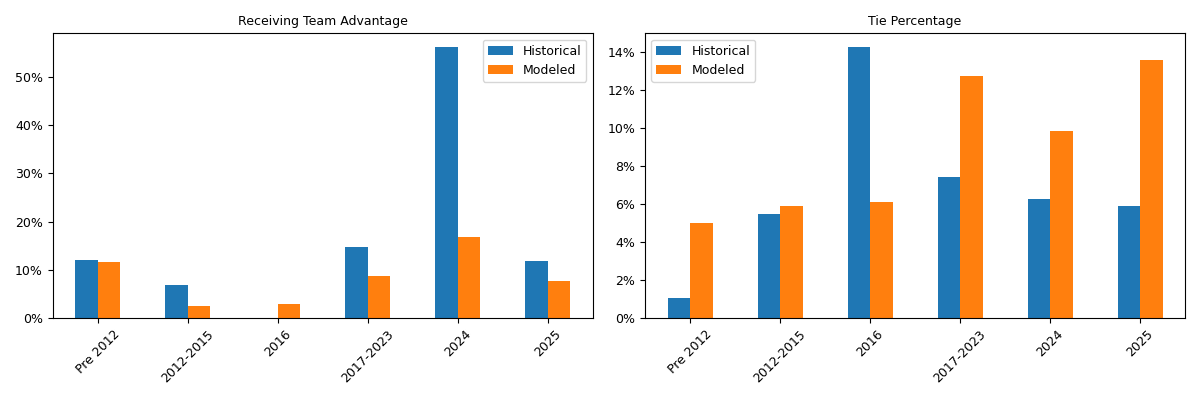

In [4]:
display(Image(filename=ASSET_DIR/HIST_ADVANTAGE_TIES))


## 2025 Rules Impact
The results show that the receiving team has a 7.6% win percentage advantage under the new overtime rules. The source of this edge is simple: nearly 80% of overtimes end within three possessions. While the kicking team has a slight edge in overtimes that end in two possessions, the receiving team has a massive advantage in overtimes that end in three possessions.

 For these purposes, "possession" is defined as an opportunity to score--typically a drive, but an interception or kick return touchdown in and of itself will count as a possession as well. The most likely outcome in overtime is ending within the first two guaranteed possessions: either team scores and the other fails to match. 57.0% of overtimes end this way. After this point the game becomes sudden-death and each possession becomes less likely than the last, as one team will either score to end the game or time will expire. 21.2% of overtimes end on the third possession, 11.9% end on the fourth possession. 5.9% on the fifth, and so on. Below is a chart showing the distribution of total possessions in the simulated overtime periods.

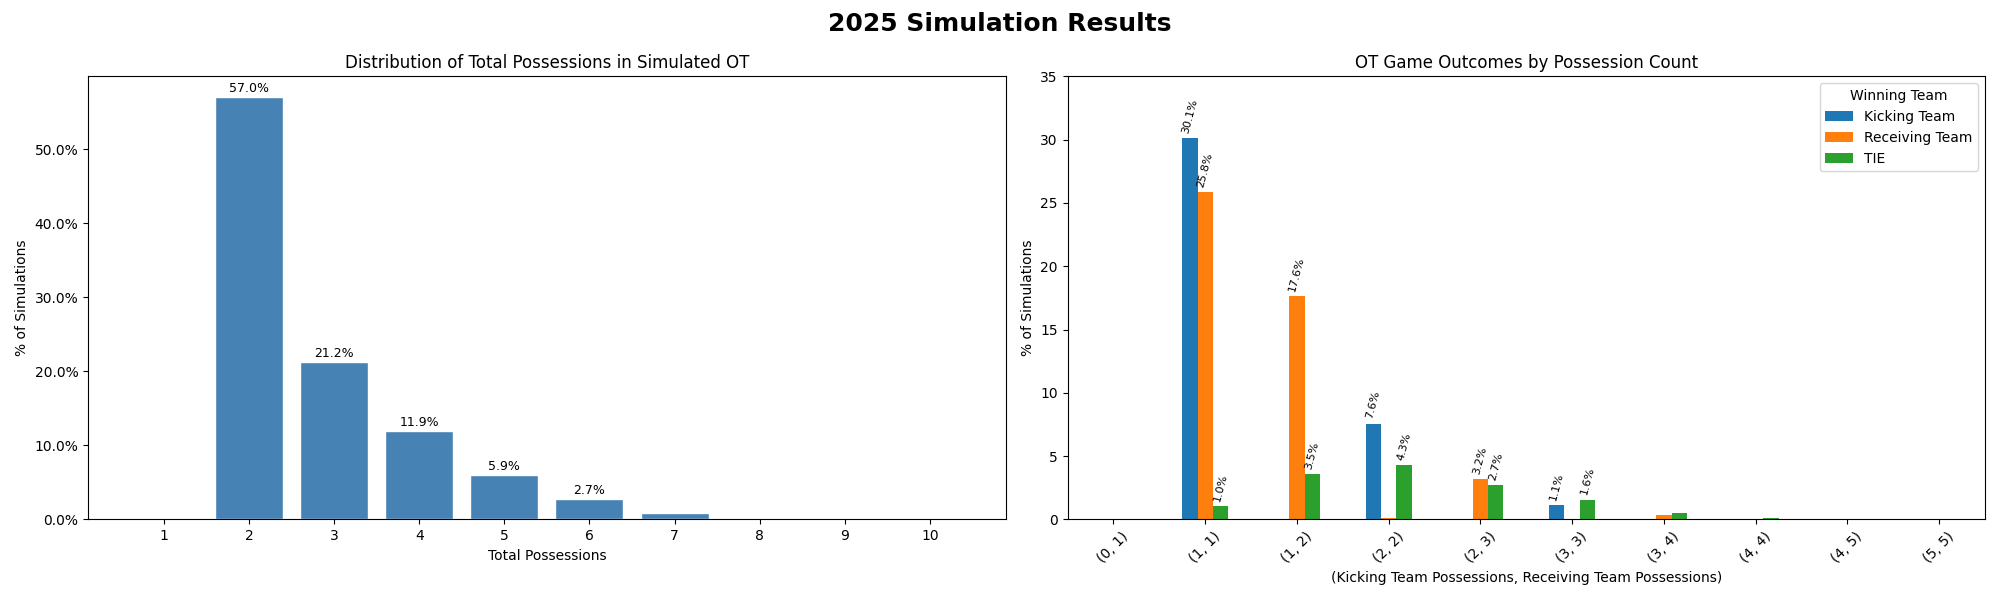

In [5]:
display(Image(filename=ASSET_DIR/POSSESSION_GRAPHS))

The second chart shows the possession distribution and winning team results for each simulation. In overtimes that end within the two guaranteed possessions, the odds favor the kicking team, who win 54.7% of these games. This is where the advantage of acting second comes into play: the kicking team knows what the receiving team accomplished and exactly what they need to match or beat, and they can deploy fourth down attempts with full information.

After the two guaranteed possessions, however, the game effectively becomes sudden-death. The only possible outcomes for games that end on a given possession are a win for the team currently in possession (as they score) or a tie if time expires. Setting ties aside, this means the receiving team wins overtimes that end on the third possession, the kicking team wins those that end on the fourth, and so on. This is the key to the receiving team's overall advantage. Once the game passes the two guaranteed possessions, it is twice as likely to end on the third possession as it is to reach a fourth, and each subsequent possession is less likely still. The third possession represents the largest swing in overtime win probability, and it belongs entirely to the receiving team.


## Kicking Team Decision Making
While the kicking team is at a disadvantage, they have some control over the outcome through their decision-making. Notably, there are two major possible decision points on the second possession. If the kicking team scores a touchdown to match the receiving team's initial score, they can go for an extra point to tie the game and continue, or go for a two-point conversion. A successful two point conversion will result in a win for the kicking team, while an unsuccessful conversion will result in a loss. Similarly, when down by three points, they can attempt a tying field goal or go for it on fourth down to continue the drive in hopes of a game-winning touchdown.

The logic behind both decisions was added to the model to determine the impact on win percentage, and 100,000 simulations were run using each combination of them. Due to their relatively low occurrence rate, a larger number of simulations was needed to conclusively determine their impact. Note that due to the increase in simulations, the win percentages are slightly different from the previous section, though in line with expectations for random simulations.

In [6]:
display(pd.read_csv(OUTPUT_DIR/OT_RESULTS_DEC).rename(columns = {
    'season':'Season',
    'games':'Games',
    'Receiving Team': '% Receiving Team Won',
    'Kicking Team': '% Kicking Team Won',
    'TIE': '% Tied'
}).style.hide(axis='index'))

Season,Go For It on Extra Points,Go For It on FG attempts,Games,% Receiving Team Won,% Kicking Team Won,% Tied,Receiving Team Advantage
2025,False,False,100000,46.52%,39.88%,13.61%,6.64%
2025,True,False,100000,47.30%,42.37%,10.32%,4.93%
2025,False,True,100000,48.06%,40.38%,11.57%,7.67%


After scoring a matching touchdown, attempting a two point conversion is the optimal decision for the kicking team. This strategy reduces the receiving team's advantage by ~1.7%, adding win equity from a reduction in the tie rate. This is consistent with the findings in the prior section--tying the game with an extra point is sending it to a third possession where the receiving team has a massive advantage. From the previous section, receiving team has a 50% win rate in overtimes that last three or more possessions. This combined with a tie rate of 30% leaves only a 20% winning rate for the kicking team in those games. The kicking team has a clear advantage on the 48% chance to convert the two-point conversion and win the game immediately compared to their comparably slim odds of winning if they allow the game to continue to a third possession.

Seemingly contradictory to the recommended aggression on two point conversions, modeled results show that the kicking team loses equity by going for fourth downs in lieu of attempting game-tying field goals. This approach reduces the tie percentage by two percent, but it favors the receiving team, as their win percentage increases 1.5% compared to the kicking team's gain of 0.5%. Based on the conclusions from two point conversions, one would expect the optimal strategy was to be aggressive to try to end the game on drive two rather than allowing the game to continue to the third possession which favors the receiving team. The difference is that converting a fourth down attempt does not guarantee a win for the receiving team. Converting the fourth down merely allows the drive to continue, the win probability at this point is not the probability of converting the fourth down, but rather it is the probability of converting the fourth down and subsequently scoring a touchdown. The odds of converting a fourth down vary by yards-to-go, but the overall conversion rate has hovered around 50%. In 2025, 46% of drives that started in typical field goal range (within the opponent's 35 yard line), resulted in a touchdown, so the odds for the kicking team at this point can be estimated 23% to win and 77% to lose going for it on fourth down when down three points in field goal range. Going to a third possession gives the kicking team a 20% chance to win or 30% chance to tie, which is a higher expected value if you assume a tie is worth half of a win, as it is measured in the standings.

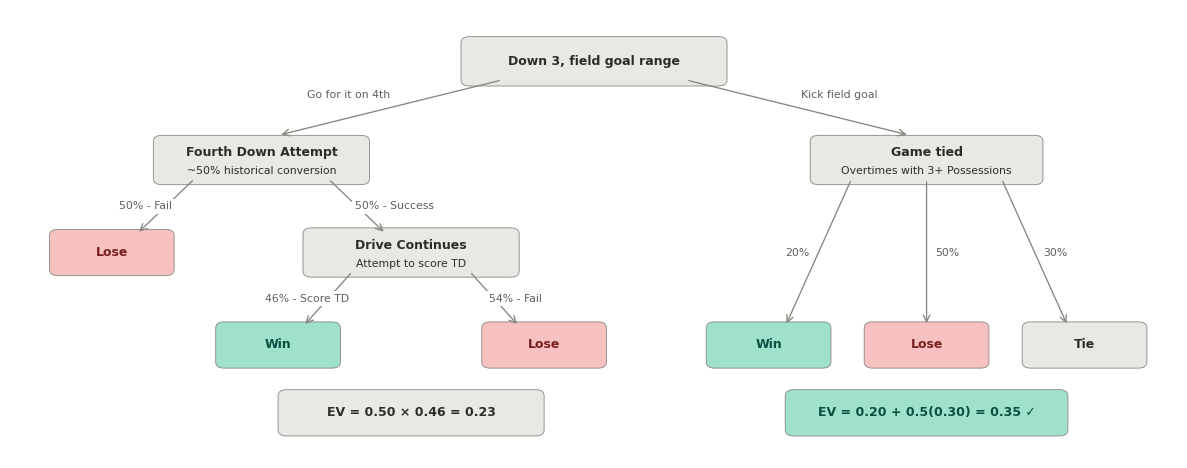

In [7]:
display(Image(filename=ASSET_DIR/DECISION_TREE))

There is likely a cutoff point of field position and yards to go in which the probability of converting on fourth down and subsequently scoring a touchdown results in a higher expected value than a game tying field goal. For example, the most extreme case would be fourth-and-one on the one-yard line--going for it almost certainly has a higher expected value than kicking a field goal from this point, but the decision is complicated as you increase the yard-to-go for the first down and get farther from the goal-line. Finding the cutoff points where the expected value tips in favor of a fourth down attempt is a further point of recommended study.

# Conclusion

While the sample size of NFL games played with the new overtime rules is too small to determine the optimal strategy, simulating the thousands of overtime periods has given insight to an optimal strategy. If a team wins the coin toss they should elect to receive, as it has a near 7% advantage in win percentage compared to kicking. The advantage of being able to end the game first once it reaches effective sudden-death outweighs the value of the information gained by the kicking team on their first drive.

The kicking team has some decision points that can improve their win percentage. If they score a touchdown to match a touchdown scored by the receiving team on their first drive, the kicking team should attempt a two point conversion. The 48% chance to convert it is higher than their chances of winning kicking off to their opponent in an effective-sudden-death situation.

It is important to note these conclusions are based on randomized simulations of generalized NFL games. They do not adapt to player, coach, or environmental specifics of each game. By simulating such a large number, the result should approach a long-run average, but it is important to note that not all situations are average. In real games, there may be contextual, strategic factors to apply that could impact overtime decisions. For example, it could be the correct strategy to kick-off in overtime if a team's defense has been dominant, if the opposing offense is tired after completing a long drive at the end of regulation, or if a coach is particularly confident in their defensive strategy. However, it is still critical to understand the structural advantage given to the receiving team when making these decisions, as a 7% win percentage advantage is a large margin to overcome.


In [9]:
%%capture
import nbformat
from nbconvert import HTMLExporter
from pathlib import Path
nb = nbformat.read("NFL_Overtime_Model.ipynb", as_version=4)
exporter = HTMLExporter(exclude_input=True, exclude_output_prompt=True)
html, _ = exporter.from_notebook_node(nb)
html = html.replace("<title>Notebook</title>", "<title>NFL Overtime Model</title>")
html = html.replace("</head>", """<style>
table { margin: 0 auto; }
.jp-OutputArea-output { display: flex; justify-content: center; }
body { padding: 0 40px; }
</style></head>""")
Path("index.html").write_text(html, encoding="utf-8")